# Stage 1 classifiers — Architecture A and B

This notebook trains and evaluates the first-stage classifier for each pipeline architecture:

- **Stage 1A**: ham vs not_normal (spam + phishing merged) — Architecture A
- **Stage 1B**: phishing vs not_phishing (ham + spam merged) — Architecture B

For each stage, Logistic Regression and Naive Bayes are compared with 5-fold cross-validation. The winner is saved to `models/07/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

BASE = "../.."

os.makedirs(f"{BASE}/models/07", exist_ok=True)
os.makedirs(f"{BASE}/reports/figures/07", exist_ok=True)

## Stage 1A — ham vs not_normal

The first classifier in Architecture A. It decides whether a message is normal (ham) or suspicious (spam or phishing combined). Any phishing message called `normal` here is permanently lost — it becomes a silent ham prediction without ever reaching Stage 2A.

In [2]:
train_a = pd.read_csv(f"{BASE}/data/processed/07/stage1a_train.csv")
test_a  = pd.read_csv(f"{BASE}/data/processed/07/stage1a_test.csv")
X_train_a, y_train_a = train_a["message"], train_a["label"]
X_test_a,  y_test_a  = test_a["message"],  test_a["label"]

print("train:", y_train_a.value_counts().to_dict())
print("test: ", y_test_a.value_counts().to_dict())

train: {'not_normal': 268886, 'normal': 138621}
test:  {'not_normal': 67222, 'normal': 34655}


In [3]:
vec_a = TfidfVectorizer(stop_words="english", max_features=3000)
X_train_a_tf = vec_a.fit_transform(X_train_a)
X_test_a_tf  = vec_a.transform(X_test_a)

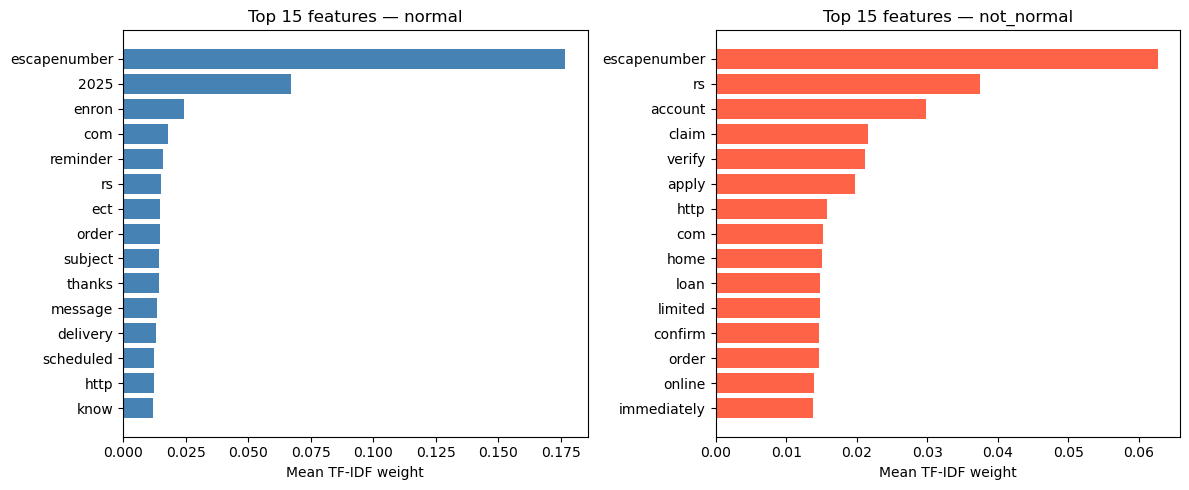

In [4]:
feature_names_a = vec_a.get_feature_names_out()
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, color in zip(axes, ["normal", "not_normal"], ["steelblue", "tomato"]):
    mask = y_train_a.values == label
    mean_scores = np.asarray(X_train_a_tf[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[-top_n:]
    ax.barh(feature_names_a[top_idx], mean_scores[top_idx], color=color)
    ax.set_title(f"Top {top_n} features — {label}")
    ax.set_xlabel("Mean TF-IDF weight")

plt.tight_layout()
plt.show()

In [5]:
candidates_a = {
    "LogisticRegression": LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    "MultinomialNB":      MultinomialNB(alpha=1.0),
}

cv_results_a = {}
for name, model in candidates_a.items():
    scores = cross_val_score(model, X_train_a_tf, y_train_a, cv=5, scoring="f1_macro")
    cv_results_a[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression: 0.9767 (+/- 0.0003)
MultinomialNB: 0.9507 (+/- 0.0005)


In [6]:
best_name_a  = max(cv_results_a, key=lambda k: cv_results_a[k].mean())
best_model_a = candidates_a[best_name_a]
best_model_a.fit(X_train_a_tf, y_train_a)
print("best:", best_name_a)

best: LogisticRegression


In [7]:
y_pred_a = best_model_a.predict(X_test_a_tf)

print(f"accuracy: {accuracy_score(y_test_a, y_pred_a):.4f}\n")
print(classification_report(y_test_a, y_pred_a))

accuracy: 0.9798

              precision    recall  f1-score   support

      normal       0.97      0.97      0.97     34655
  not_normal       0.98      0.99      0.98     67222

    accuracy                           0.98    101877
   macro avg       0.98      0.98      0.98    101877
weighted avg       0.98      0.98      0.98    101877



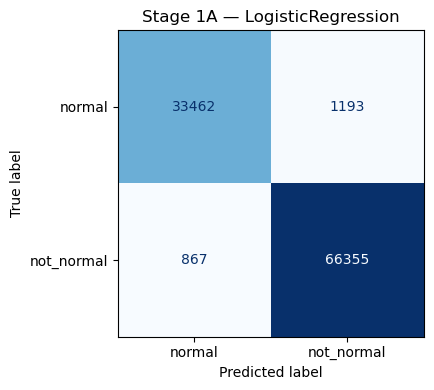

In [8]:
cm_a = confusion_matrix(y_test_a, y_pred_a, labels=["normal", "not_normal"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_a, display_labels=["normal", "not_normal"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Stage 1A — {best_name_a}")
plt.tight_layout()
plt.savefig(f"{BASE}/reports/figures/07/stage1a_cm.png", dpi=150)
plt.show()

In [9]:
with open(f"{BASE}/models/07/stage1a_model.pkl", "wb") as f:
    pickle.dump(best_model_a, f)
with open(f"{BASE}/models/07/stage1a_vectorizer.pkl", "wb") as f:
    pickle.dump(vec_a, f)
print("saved stage1a_model.pkl and stage1a_vectorizer.pkl")

saved stage1a_model.pkl and stage1a_vectorizer.pkl


## Stage 1B — phishing vs not_phishing

The first classifier in Architecture B. It separates phishing from everything else (ham + spam merged into `not_phishing`). Messages it calls `not_phishing` go on to Stage 2B.

Note: phishing is only ~16% of the training data — a harder class imbalance than Stage 1A (~34% normal).

In [10]:
train_b = pd.read_csv(f"{BASE}/data/processed/07/stage1b_train.csv")
test_b  = pd.read_csv(f"{BASE}/data/processed/07/stage1b_test.csv")
X_train_b, y_train_b = train_b["message"], train_b["label"]
X_test_b,  y_test_b  = test_b["message"],  test_b["label"]

print("train:", y_train_b.value_counts().to_dict())
print("test: ", y_test_b.value_counts().to_dict())

train: {'not_phishing': 338840, 'phishing': 68667}
test:  {'not_phishing': 84710, 'phishing': 17167}


In [11]:
vec_b = TfidfVectorizer(stop_words="english", max_features=3000)
X_train_b_tf = vec_b.fit_transform(X_train_b)
X_test_b_tf  = vec_b.transform(X_test_b)

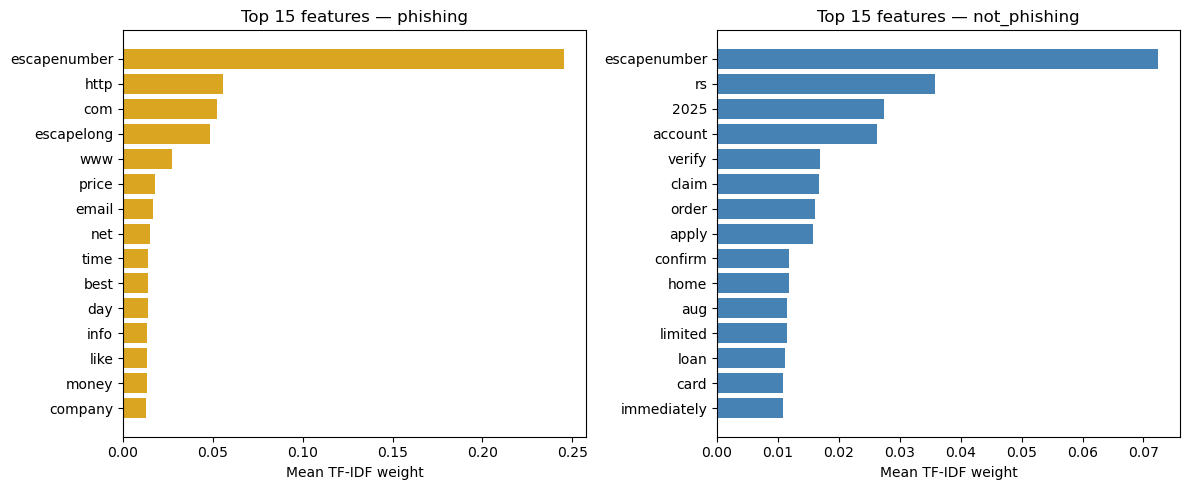

In [12]:
feature_names_b = vec_b.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, color in zip(axes, ["phishing", "not_phishing"], ["goldenrod", "steelblue"]):
    mask = y_train_b.values == label
    mean_scores = np.asarray(X_train_b_tf[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[-top_n:]
    ax.barh(feature_names_b[top_idx], mean_scores[top_idx], color=color)
    ax.set_title(f"Top {top_n} features — {label}")
    ax.set_xlabel("Mean TF-IDF weight")

plt.tight_layout()
plt.show()

In [13]:
candidates_b = {
    "LogisticRegression": LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    "MultinomialNB":      MultinomialNB(alpha=1.0),
}

cv_results_b = {}
for name, model in candidates_b.items():
    scores = cross_val_score(model, X_train_b_tf, y_train_b, cv=5, scoring="f1_macro")
    cv_results_b[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression: 0.9034 (+/- 0.0012)
MultinomialNB: 0.8654 (+/- 0.0010)


In [14]:
best_name_b  = max(cv_results_b, key=lambda k: cv_results_b[k].mean())
best_model_b = candidates_b[best_name_b]
best_model_b.fit(X_train_b_tf, y_train_b)
print("best:", best_name_b)

best: LogisticRegression


In [15]:
y_pred_b = best_model_b.predict(X_test_b_tf)

print(f"accuracy: {accuracy_score(y_test_b, y_pred_b):.4f}\n")
print(classification_report(y_test_b, y_pred_b))

accuracy: 0.9457

              precision    recall  f1-score   support

not_phishing       0.97      0.97      0.97     84710
    phishing       0.85      0.83      0.84     17167

    accuracy                           0.95    101877
   macro avg       0.91      0.90      0.90    101877
weighted avg       0.95      0.95      0.95    101877



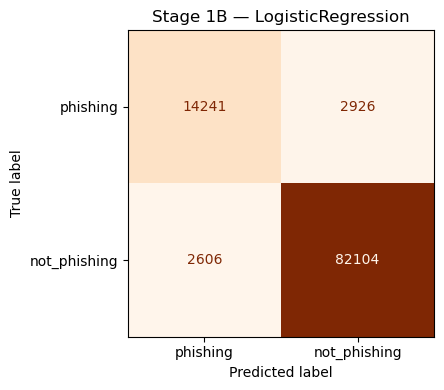

In [16]:
cm_b = confusion_matrix(y_test_b, y_pred_b, labels=["phishing", "not_phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_b, display_labels=["phishing", "not_phishing"]).plot(
    ax=ax, cmap="Oranges", colorbar=False
)
ax.set_title(f"Stage 1B — {best_name_b}")
plt.tight_layout()
plt.savefig(f"{BASE}/reports/figures/07/stage1b_cm.png", dpi=150)
plt.show()

In [17]:
with open(f"{BASE}/models/07/stage1b_model.pkl", "wb") as f:
    pickle.dump(best_model_b, f)
with open(f"{BASE}/models/07/stage1b_vectorizer.pkl", "wb") as f:
    pickle.dump(vec_b, f)
print("saved stage1b_model.pkl and stage1b_vectorizer.pkl")

saved stage1b_model.pkl and stage1b_vectorizer.pkl
